In [ ]:
!pip install copulas python-binance -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.3/149.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 37.4 MB/s eta 0:00:00


Pull BTC and ETH hourly data

In [ ]:
import requests
import pandas as pd

def get_klines(symbol, interval="1h", limit=1000):
    url = "https://data-api.binance.vision/api/v3/klines"
    params = {"symbol": symbol, "interval": interval, "limit": limit}
    resp = requests.get(url, params=params)
    resp.raise_for_status()
    data = resp.json()
    df = pd.DataFrame(data, columns=[
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_volume", "trades",
        "taker_buy_base", "taker_buy_quote", "ignore"
    ])
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms")
    for col in ["open", "high", "low", "close", "volume"]:
        df[col] = df[col].astype(float)
    return df[["open_time", "close"]].rename(columns={"close": symbol})

btc = get_klines("BTCUSDT")
eth = get_klines("ETHUSDT")

print(btc.tail())
print(eth.tail())

              open_time   BTCUSDT
995 2026-09-15 10:00:00  77053.80
996 2026-09-15 11:00:00  76940.01
997 2026-09-15 12:00:00  76957.65
998 2026-09-15 13:00:00  76618.77
999 2026-09-15 14:00:00  76406.34
              open_time  ETHUSDT
995 2026-09-15 10:00:00  2483.68
996 2026-09-15 11:00:00  2476.41
997 2026-09-15 12:00:00  2479.19
998 2026-09-15 13:00:00  2454.04
999 2026-09-15 14:00:00  2446.86


Merge and check correlation

BTC-ETH hourly return correlation: 0.8397


array([<Axes: xlabel='open_time'>, <Axes: xlabel='open_time'>],
      dtype=object)

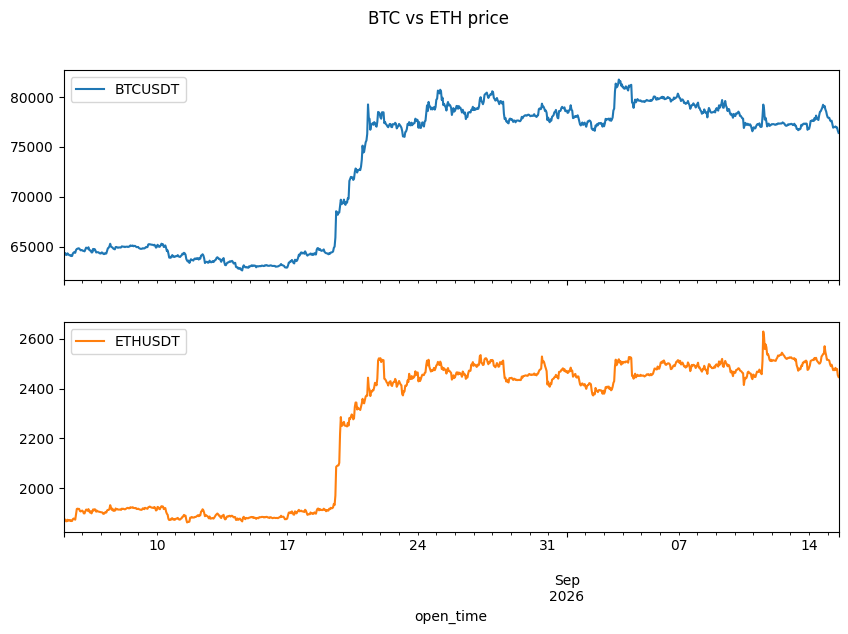

In [ ]:
df = pd.merge(btc, eth, on="open_time")
df["btc_return"] = df["BTCUSDT"].pct_change()
df["eth_return"] = df["ETHUSDT"].pct_change()
df = df.dropna()

correlation = df["btc_return"].corr(df["eth_return"])
print(f"BTC-ETH hourly return correlation: {correlation:.4f}")

df.plot(x="open_time", y=["BTCUSDT", "ETHUSDT"], subplots=True, figsize=(10,6), title="BTC vs ETH price")

Quick Visuals: Are returns actually comoving

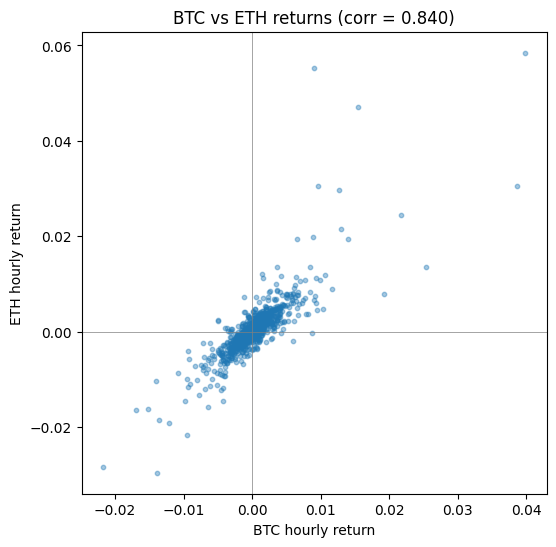

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(df["btc_return"], df["eth_return"], alpha=0.4, s=10)
plt.xlabel("BTC hourly return")
plt.ylabel("ETH hourly return")
plt.title(f"BTC vs ETH returns (corr = {correlation:.3f})")
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.show()

Naive (independence) probability vs. empirical joint probability

In [ ]:
# Naive: treat as independent
p_btc_up = (df["btc_return"] > 0).mean()
p_eth_up = (df["eth_return"] > 0).mean()
naive_joint_prob = p_btc_up * p_eth_up

# Empirical: actual joint frequency observed in the data
empirical_joint_prob = ((df["btc_return"] > 0) & (df["eth_return"] > 0)).mean()

print(f"P(BTC up) = {p_btc_up:.4f}")
print(f"P(ETH up) = {p_eth_up:.4f}")
print(f"Naive P(BTC up AND ETH up) = {naive_joint_prob:.4f}")
print(f"Empirical P(BTC up AND ETH up) = {empirical_joint_prob:.4f}")
print(f"Mispricing gap = {empirical_joint_prob - naive_joint_prob:.4f}")

P(BTC up) = 0.5045
P(ETH up) = 0.5025
Naive P(BTC up AND ETH up) = 0.2535
Empirical P(BTC up AND ETH up) = 0.4184
Mispricing gap = 0.1649


Fit a Gaussian copula and see if it captures this better than naive

In [ ]:
from copulas.multivariate import GaussianMultivariate

copula_data = df[["btc_return", "eth_return"]]
copula = GaussianMultivariate()
copula.fit(copula_data)

# Simulate from the fitted copula
samples = copula.sample(10000)
copula_joint_prob = ((samples["btc_return"] > 0) & (samples["eth_return"] > 0)).mean()

print(f"Copula-implied P(BTC up AND ETH up) = {copula_joint_prob:.4f}")
print(f"Empirical (ground truth)            = {empirical_joint_prob:.4f}")
print(f"Naive independence                  = {naive_joint_prob:.4f}")

/usr/local/lib/python3.13/dist-packages/scipy/stats/_continuous_distns.py:796: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/usr/local/lib/python3.13/dist-packages/scipy/stats/_continuous_distns.py:801: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))
/usr/local/lib/python3.13/dist-packages/scipy/stats/_continuous_distns.py:6738: RuntimeWarning: divide by zero encountered in power
  return cd2*x**(c-1)
/usr/local/lib/python3.13/dist-packages/scipy/stats/_continuous_distns.py:796: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/usr/local/lib/python3.13/dist-packages/scipy/stats/_continuous_distns.py:801: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize

Copula-implied P(BTC up AND ETH up) = 0.4166
Empirical (ground truth)            = 0.4184
Naive independence                  = 0.2535


Fit a t-copula and compare

In [ ]:
from copulas.multivariate import GaussianMultivariate
from copulas.univariate import GaussianKDE
import numpy as np

# Refit Gaussian for a clean side-by-side (reuse if already fit)
gaussian_copula = GaussianMultivariate()
gaussian_copula.fit(df[["btc_return", "eth_return"]])

# For t-copula, we'll use scipy directly since 'copulas' package doesn't have native t-copula
from scipy import stats

def fit_t_copula(data, df_dof=4):
    # Transform to uniform marginals via empirical CDF (pseudo-observations)
    u = data.rank() / (len(data) + 1)
    # Transform uniforms to t-distribution quantiles
    t_quantiles = stats.t.ppf(u, df=df_dof)
    corr_matrix = np.corrcoef(t_quantiles.T)
    return corr_matrix, df_dof

corr_matrix, dof = fit_t_copula(df[["btc_return", "eth_return"]])
print("t-copula correlation matrix:\n", corr_matrix)

# Simulate from fitted t-copula
n_sims = 10000
mvt_samples = stats.multivariate_t.rvs(shape=corr_matrix, df=dof, size=n_sims)
u_samples = stats.t.cdf(mvt_samples, df=dof)

# Map back to actual return distributions using empirical quantiles
btc_sim = np.quantile(df["btc_return"], u_samples[:, 0])
eth_sim = np.quantile(df["eth_return"], u_samples[:, 1])

t_copula_joint_prob = ((btc_sim > 0) & (eth_sim > 0)).mean()

print(f"\nNaive independence:      {naive_joint_prob:.4f}")
print(f"Empirical (ground truth): {empirical_joint_prob:.4f}")
print(f"Gaussian copula:          {copula_joint_prob:.4f}")
print(f"t-copula (df={dof}):          {t_copula_joint_prob:.4f}")

/usr/local/lib/python3.13/dist-packages/scipy/stats/_continuous_distns.py:796: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/usr/local/lib/python3.13/dist-packages/scipy/stats/_continuous_distns.py:801: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))
/usr/local/lib/python3.13/dist-packages/scipy/stats/_continuous_distns.py:6738: RuntimeWarning: divide by zero encountered in power
  return cd2*x**(c-1)
/usr/local/lib/python3.13/dist-packages/scipy/stats/_continuous_distns.py:796: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/usr/local/lib/python3.13/dist-packages/scipy/stats/_continuous_distns.py:801: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize

t-copula correlation matrix:
 [[1.        0.8747554]
 [0.8747554 1.       ]]

Naive independence:      0.2535
Empirical (ground truth): 0.4184
Gaussian copula:          0.4166
t-copula (df=4):          0.4304


/usr/local/lib/python3.13/dist-packages/scipy/stats/_continuous_distns.py:6738: RuntimeWarning: divide by zero encountered in power
  return cd2*x**(c-1)


Robustness — does this hold across horizons and thresholds? Test at daily granularity

In [ ]:
btc_daily = get_klines("BTCUSDT", interval="1d", limit=1000)
eth_daily = get_klines("ETHUSDT", interval="1d", limit=1000)

df_daily = pd.merge(btc_daily, eth_daily, on="open_time")
df_daily["btc_return"] = df_daily["BTCUSDT"].pct_change()
df_daily["eth_return"] = df_daily["ETHUSDT"].pct_change()
df_daily = df_daily.dropna()

corr_daily = df_daily["btc_return"].corr(df_daily["eth_return"])
naive_daily = (df_daily["btc_return"] > 0).mean() * (df_daily["eth_return"] > 0).mean()
empirical_daily = ((df_daily["btc_return"] > 0) & (df_daily["eth_return"] > 0)).mean()

print(f"Daily correlation: {corr_daily:.4f}")
print(f"Naive:     {naive_daily:.4f}")
print(f"Empirical: {empirical_daily:.4f}")
print(f"Gap:       {empirical_daily - naive_daily:.4f}")

Daily correlation: 0.8173
Naive:     0.2560
Empirical: 0.4154
Gap:       0.1594


Test at a stricter threshold (bigger moves, not just "up")

In [ ]:
threshold = 0.01  # 1% move, not just any positive move

p_btc_big_up = (df["btc_return"] > threshold).mean()
p_eth_big_up = (df["eth_return"] > threshold).mean()
naive_big = p_btc_big_up * p_eth_big_up
empirical_big = ((df["btc_return"] > threshold) & (df["eth_return"] > threshold)).mean()

print(f"P(BTC > {threshold*100}%): {p_btc_big_up:.4f}")
print(f"P(ETH > {threshold*100}%): {p_eth_big_up:.4f}")
print(f"Naive joint:     {naive_big:.4f}")
print(f"Empirical joint: {empirical_big:.4f}")
print(f"Ratio (empirical/naive): {empirical_big/naive_big:.2f}x")

P(BTC > 1.0%): 0.0120
P(ETH > 1.0%): 0.0230
Naive joint:     0.0003
Empirical joint: 0.0090
Ratio (empirical/naive): 32.58x


Part 3: Monte Carlo as an independent-check approach

Simulate correlated paths directly via Cholesky decomposition

In [ ]:
# Direct Monte Carlo: simulate correlated normal returns using observed covariance
mean_returns = df[["btc_return", "eth_return"]].mean().values
cov_matrix = df[["btc_return", "eth_return"]].cov().values

mc_samples = np.random.multivariate_normal(mean_returns, cov_matrix, size=10000)
mc_joint_prob = ((mc_samples[:, 0] > 0) & (mc_samples[:, 1] > 0)).mean()

print(f"Monte Carlo (multivariate normal): {mc_joint_prob:.4f}")
print(f"Gaussian copula:                    {copula_joint_prob:.4f}")
print(f"t-copula:                            {t_copula_joint_prob:.4f}")
print(f"Empirical:                           {empirical_joint_prob:.4f}")

Monte Carlo (multivariate normal): 0.4315
Gaussian copula:                    0.4166
t-copula:                            0.4304
Empirical:                           0.4184


rerun the copula comparison at the 1% threshold specifically

In [ ]:
# Sample from Gaussian and t-copula, check tail threshold performance
threshold = 0.01

gaussian_tail_prob = ((samples["btc_return"] > threshold) & (samples["eth_return"] > threshold)).mean()
t_copula_tail_prob = ((btc_sim > threshold) & (eth_sim > threshold)).mean()

print(f"Naive independence:       {naive_big:.5f}")
print(f"Empirical (ground truth): {empirical_big:.5f}")
print(f"Gaussian copula:          {gaussian_tail_prob:.5f}")
print(f"t-copula:                 {t_copula_tail_prob:.5f}")

Naive independence:       0.00028
Empirical (ground truth): 0.00901
Gaussian copula:          0.00990
t-copula:                 0.01030


Train/test split and out-of-sample validation

In [ ]:
# Split into train (first 70%) and test (last 30%) — no shuffling, since this is time series
split_idx = int(len(df) * 0.7)
train = df.iloc[:split_idx].copy()
test = df.iloc[split_idx:].copy()

print(f"Train: {len(train)} rows ({train['open_time'].min()} to {train['open_time'].max()})")
print(f"Test:  {len(test)} rows ({test['open_time'].min()} to {test['open_time'].max()})")

Train: 699 rows (2026-08-05 00:00:00 to 2026-09-03 02:00:00)
Test:  300 rows (2026-09-03 03:00:00 to 2026-09-15 14:00:00)


Fit copulas on train only, evaluate on test

In [ ]:
from copulas.multivariate import GaussianMultivariate
from scipy import stats
import numpy as np

threshold = 0.01

# --- Naive (fit on train stats, apply formula to test) ---
p_btc_train = (train["btc_return"] > threshold).mean()
p_eth_train = (train["eth_return"] > threshold).mean()
naive_prob = p_btc_train * p_eth_train

# --- Gaussian copula: fit on train, simulate, check against test threshold ---
gaussian_copula_oos = GaussianMultivariate()
gaussian_copula_oos.fit(train[["btc_return", "eth_return"]])
gauss_samples = gaussian_copula_oos.sample(10000)
gaussian_prob = ((gauss_samples["btc_return"] > threshold) & (gauss_samples["eth_return"] > threshold)).mean()

# --- t-copula: fit on train ---
def fit_t_copula(data, df_dof=4):
    u = data.rank() / (len(data) + 1)
    t_quantiles = stats.t.ppf(u, df=df_dof)
    corr_matrix = np.corrcoef(t_quantiles.T)
    return corr_matrix, df_dof

corr_matrix_train, dof = fit_t_copula(train[["btc_return", "eth_return"]])
mvt_samples = stats.multivariate_t.rvs(shape=corr_matrix_train, df=dof, size=10000)
u_samples = stats.t.cdf(mvt_samples, df=dof)

# map back using TRAIN quantiles only (no test leakage)
btc_sim = np.quantile(train["btc_return"], u_samples[:, 0])
eth_sim = np.quantile(train["eth_return"], u_samples[:, 1])
t_copula_prob = ((btc_sim > threshold) & (eth_sim > threshold)).mean()

# --- Ground truth: actual empirical rate in TEST set (never seen by any model) ---
empirical_test_prob = ((test["btc_return"] > threshold) & (test["eth_return"] > threshold)).mean()

print(f"Naive independence (train stats): {naive_prob:.5f}")
print(f"Gaussian copula (train-fit):       {gaussian_prob:.5f}")
print(f"t-copula (train-fit):              {t_copula_prob:.5f}")
print(f"Empirical (TEST set, unseen):      {empirical_test_prob:.5f}")

/usr/local/lib/python3.13/dist-packages/scipy/stats/_continuous_distns.py:796: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/usr/local/lib/python3.13/dist-packages/scipy/stats/_continuous_distns.py:801: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))
/usr/local/lib/python3.13/dist-packages/scipy/stats/_continuous_distns.py:796: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/usr/local/lib/python3.13/dist-packages/scipy/stats/_continuous_distns.py:801: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))
/usr/local/lib/python3.13/dist-packages/scipy/stats/_continuous_distns.py:6738: RuntimeWarning: divide by zero encountered in po

Naive independence (train stats): 0.00031
Gaussian copula (train-fit):       0.00780
t-copula (train-fit):              0.00870
Empirical (TEST set, unseen):      0.01000


Convert probabilities to binary contract prices

In [ ]:
# A binary contract paying $1 if "BTC > 1% AND ETH > 1%" is fair-priced at the probability itself
# (in prediction-market convention, prices are quoted in cents, 0-100)

naive_price = naive_prob * 100       # cents
gaussian_price = gaussian_prob * 100
t_copula_price = t_copula_prob * 100
true_price = empirical_test_prob * 100  # what it "should" be priced at, based on unseen reality

print(f"Naive-priced contract:     {naive_price:.2f}¢")
print(f"Gaussian copula price:     {gaussian_price:.2f}¢")
print(f"t-copula price:            {t_copula_price:.2f}¢")
print(f"'True' price (test data):  {true_price:.2f}¢")

Naive-priced contract:     0.03¢
Gaussian copula price:     0.78¢
t-copula price:            0.87¢
'True' price (test data):  1.00¢


Quantify the trading edge from mispricing

In [ ]:
contract_payout = 100  # cents, if event occurs

# Scenario: naive market maker sells 1000 contracts at the naive price
n_contracts = 1000
naive_revenue = naive_price * n_contracts / 100   # dollars collected upfront
expected_payout_true = true_price / 100 * contract_payout * n_contracts / 100  # expected cost, using TRUE probability

expected_pnl_naive_seller = naive_revenue - expected_payout_true

print(f"Naive market maker sells {n_contracts} contracts at {naive_price:.2f}¢ each")
print(f"Revenue collected:        ${naive_revenue:.2f}")
print(f"Expected payout (true p): ${expected_payout_true:.2f}")
print(f"Expected P&L:             ${expected_pnl_naive_seller:.2f}  <-- negative = naive MM loses money on average")

Naive market maker sells 1000 contracts at 0.03¢ each
Revenue collected:        $0.31
Expected payout (true p): $10.00
Expected P&L:             $-9.69  <-- negative = naive MM loses money on average


Add a market-making spread around your (better) fair value

In [ ]:
def make_market(fair_price_cents, base_spread=0.5, confidence_width=None):
    """
    fair_price_cents: your model's fair value estimate (0-100)
    base_spread: minimum spread in cents
    confidence_width: optional — widen spread if models disagree (uncertainty proxy)
    """
    spread = base_spread
    if confidence_width:
        spread += confidence_width  # wider spread when models disagree = more uncertain

    bid = max(0, fair_price_cents - spread / 2)
    ask = min(100, fair_price_cents + spread / 2)
    return bid, ask

# Use t-copula as your "best" fair value estimate
model_disagreement = abs(gaussian_price - t_copula_price)  # proxy for model uncertainty

bid, ask = make_market(t_copula_price, base_spread=0.3, confidence_width=model_disagreement)
print(f"Fair value (t-copula):  {t_copula_price:.2f}¢")
print(f"Model disagreement:     {model_disagreement:.2f}¢ (Gaussian vs t-copula)")
print(f"Quoted market:          {bid:.2f}¢ / {ask:.2f}¢")

Fair value (t-copula):  0.87¢
Model disagreement:     0.09¢ (Gaussian vs t-copula)
Quoted market:          0.67¢ / 1.06¢


quoting engine

In [ ]:
!pip install copulas websockets -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 2.2 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import asyncio
import json
import time
from collections import deque
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import requests
from scipy import stats

try:
    from copulas.multivariate import GaussianMultivariate
    HAS_COPULAS = True
except ImportError:
    HAS_COPULAS = False


# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

SYMBOL_A = "BTCUSDT"
SYMBOL_B = "ETHUSDT"
COMBO_THRESHOLD = 0.01
ROLLING_WINDOW = 300
REFIT_EVERY_N_TICKS = 20
BASE_SPREAD_CENTS = 0.3
MAX_SPREAD_CENTS = 6.0
INVENTORY_LIMIT = 20
CONTRACT_PAYOUT = 100.0
WARM_START = 200


# ---------------------------------------------------------------------------
# Fair value model
# ---------------------------------------------------------------------------

class ComboFairValueModel:
    def __init__(self, threshold=COMBO_THRESHOLD, t_dof=4):
        self.threshold = threshold
        self.t_dof = t_dof

    def fit_and_price(self, returns_df: pd.DataFrame):
        if len(returns_df) < 50:
            return None

        p_a = (returns_df["ret_a"] > self.threshold).mean()
        p_b = (returns_df["ret_b"] > self.threshold).mean()
        naive_prob = p_a * p_b

        gaussian_prob = naive_prob
        if HAS_COPULAS:
            try:
                gc = GaussianMultivariate()
                gc.fit(returns_df[["ret_a", "ret_b"]])
                samples = gc.sample(3000)
                gaussian_prob = (
                    (samples["ret_a"] > self.threshold)
                    & (samples["ret_b"] > self.threshold)
                ).mean()
            except Exception:
                pass

        u = returns_df[["ret_a", "ret_b"]].rank() / (len(returns_df) + 1)
        t_quantiles = stats.t.ppf(u, df=self.t_dof)
        corr_matrix = np.nan_to_num(np.corrcoef(t_quantiles.T), nan=0.0)
        np.fill_diagonal(corr_matrix, 1.0)

        try:
            mvt_samples = stats.multivariate_t.rvs(shape=corr_matrix, df=self.t_dof, size=3000)
            u_samples = stats.t.cdf(mvt_samples, df=self.t_dof)
            a_sim = np.quantile(returns_df["ret_a"], u_samples[:, 0])
            b_sim = np.quantile(returns_df["ret_b"], u_samples[:, 1])
            t_copula_prob = ((a_sim > self.threshold) & (b_sim > self.threshold)).mean()
        except Exception:
            t_copula_prob = gaussian_prob

        blended_prob = (gaussian_prob + t_copula_prob) / 2.0
        disagreement = abs(gaussian_prob - t_copula_prob)

        return {
            "naive_cents": naive_prob * 100,
            "fair_value_cents": blended_prob * 100,
            "disagreement_cents": disagreement * 100,
        }


# ---------------------------------------------------------------------------
# Inventory + quoting
# ---------------------------------------------------------------------------

@dataclass
class Inventory:
    position: int = 0
    cash_cents: float = 0.0
    trade_log: list = field(default_factory=list)

    def apply_fill(self, side, price_cents, size, timestamp):
        if side == "sell":
            self.position -= size
            self.cash_cents += price_cents * size
        else:
            self.position += size
            self.cash_cents -= price_cents * size
        self.trade_log.append({"time": timestamp, "side": side, "price": price_cents, "size": size})

    def settle(self, event_occurred: bool):
        payout = CONTRACT_PAYOUT if event_occurred else 0.0
        settlement_pnl = self.position * payout
        self.cash_cents += settlement_pnl
        return settlement_pnl


class QuotingEngine:
    def __init__(self, mode="copula"):
        self.mode = mode
        self.inventory = Inventory()

    def inventory_skew_cents(self):
        imbalance_ratio = self.inventory.position / INVENTORY_LIMIT
        imbalance_ratio = max(-1.0, min(1.0, imbalance_ratio))
        extra_spread = (imbalance_ratio ** 2) * (MAX_SPREAD_CENTS - BASE_SPREAD_CENTS)
        skew = -imbalance_ratio * (extra_spread / 2.0)
        return extra_spread, skew

    def get_quote(self, pricing_result):
        fair_value = (
            pricing_result["fair_value_cents"] if self.mode == "copula"
            else pricing_result["naive_cents"]
        )
        disagreement = pricing_result["disagreement_cents"] if self.mode == "copula" else 0.0

        extra_spread_inv, skew = self.inventory_skew_cents()
        total_spread = min(MAX_SPREAD_CENTS, BASE_SPREAD_CENTS + disagreement + extra_spread_inv)
        mid = fair_value + skew
        bid = max(0.0, mid - total_spread / 2)
        ask = min(100.0, mid + total_spread / 2)
        return round(bid, 3), round(ask, 3)


# ---------------------------------------------------------------------------
# Data
# ---------------------------------------------------------------------------

def fetch_klines_paginated(symbol, interval="1h", total=3000):
    url = "https://data-api.binance.vision/api/v3/klines"
    all_rows = []
    end_time = None
    remaining = total

    while remaining > 0:
        batch = min(1000, remaining)
        params = {"symbol": symbol, "interval": interval, "limit": batch}
        if end_time is not None:
            params["endTime"] = end_time
        resp = requests.get(url, params=params, timeout=10)
        resp.raise_for_status()
        rows = resp.json()
        if not rows:
            break
        all_rows = rows + all_rows
        end_time = rows[0][0] - 1
        remaining -= len(rows)
        if len(rows) < batch:
            break

    df = pd.DataFrame(all_rows, columns=[
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_volume", "trades",
        "taker_buy_base", "taker_buy_quote", "ignore",
    ])
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms")
    df["close"] = df["close"].astype(float)
    df = df.drop_duplicates(subset="open_time").sort_values("open_time")
    return df[["open_time", "close"]].rename(columns={"close": symbol})


def build_return_series(total=3000, interval="1h"):
    a = fetch_klines_paginated(SYMBOL_A, interval=interval, total=total)
    b = fetch_klines_paginated(SYMBOL_B, interval=interval, total=total)
    merged = pd.merge(a, b, on="open_time")
    merged["ret_a"] = merged[SYMBOL_A].pct_change()
    merged["ret_b"] = merged[SYMBOL_B].pct_change()
    return merged.dropna().reset_index(drop=True)


# ---------------------------------------------------------------------------
# Synthetic order flow
# ---------------------------------------------------------------------------

def simulate_incoming_order(bid, ask, rng):
    if rng.random() > 0.3:
        return None
    size = int(rng.integers(1, 5))
    if rng.random() < 0.5:
        return {"side": "buy", "price": ask, "size": size}
    else:
        return {"side": "sell", "price": bid, "size": size}


# ---------------------------------------------------------------------------
# Single trial
# ---------------------------------------------------------------------------

def run_single_trial(full_series, start_idx, n_ticks, quoting_mode, seed, verbose=False):
    model = ComboFairValueModel()
    engine = QuotingEngine(mode=quoting_mode)
    rng = np.random.default_rng(seed)

    history = deque(maxlen=ROLLING_WINDOW)
    warm = full_series.iloc[max(0, start_idx - WARM_START):start_idx]
    for _, row in warm.iterrows():
        history.append((row["ret_a"], row["ret_b"]))

    trial_slice = full_series.iloc[start_idx:start_idx + n_ticks].reset_index(drop=True)
    if len(trial_slice) < n_ticks:
        return None

    last_pricing = None
    for i, row in trial_slice.iterrows():
        history.append((row["ret_a"], row["ret_b"]))

        if i % REFIT_EVERY_N_TICKS == 0 or last_pricing is None:
            hist_df = pd.DataFrame(history, columns=["ret_a", "ret_b"])
            result = model.fit_and_price(hist_df)
            if result:
                last_pricing = result

        if last_pricing is None:
            continue

        bid, ask = engine.get_quote(last_pricing)
        order = simulate_incoming_order(bid, ask, rng)
        if order:
            our_side = "sell" if order["side"] == "buy" else "buy"
            engine.inventory.apply_fill(our_side, order["price"], order["size"], row["open_time"])

        if verbose and i % 50 == 0:
            print(f"  [{quoting_mode}] tick {i}: fair={last_pricing['fair_value_cents']:.3f}c "
                  f"quote={bid:.3f}/{ask:.3f} pos={engine.inventory.position}")

    event_occurred = bool(
        ((trial_slice["ret_a"] > COMBO_THRESHOLD) & (trial_slice["ret_b"] > COMBO_THRESHOLD)).any()
    )
    settlement_pnl = engine.inventory.settle(event_occurred)

    return {
        "mode": quoting_mode,
        "start_idx": start_idx,
        "final_position": engine.inventory.position,
        "n_trades": len(engine.inventory.trade_log),
        "event_occurred": event_occurred,
        "settlement_pnl_usd": settlement_pnl / 100,
        "total_pnl_usd": engine.inventory.cash_cents / 100,
    }


# ---------------------------------------------------------------------------
# Multi-trial comparison
# ---------------------------------------------------------------------------

def run_multi_trial(n_trials=15, ticks_per_trial=200, total_history=4000):
    print(f"Fetching ~{total_history} hourly candles for {n_trials} non-overlapping trials...")
    full_series = build_return_series(total=total_history, interval="1h")

    max_start = len(full_series) - ticks_per_trial
    usable_trials = min(n_trials, max(1, (max_start - WARM_START) // ticks_per_trial))
    if usable_trials < n_trials:
        print(f"Note: only enough data for {usable_trials} non-overlapping trials "
              f"(requested {n_trials}) — proceeding with {usable_trials}.")

    naive_results, copula_results = [], []

    for t in range(usable_trials):
        start_idx = WARM_START + t * ticks_per_trial
        seed = 1000 + t

        naive_res = run_single_trial(full_series, start_idx, ticks_per_trial, "naive", seed)
        copula_res = run_single_trial(full_series, start_idx, ticks_per_trial, "copula", seed)

        if naive_res is None or copula_res is None:
            continue

        naive_results.append(naive_res)
        copula_results.append(copula_res)

        print(f"Trial {t+1:>2}/{usable_trials}  "
              f"event={str(naive_res['event_occurred']):<5}  "
              f"naive_pnl=${naive_res['total_pnl_usd']:>7.2f}  "
              f"copula_pnl=${copula_res['total_pnl_usd']:>7.2f}")

    summarize(naive_results, copula_results)
    return naive_results, copula_results   # <-- now returns results for further analysis


def summarize(naive_results, copula_results):
    naive_pnls = np.array([r["total_pnl_usd"] for r in naive_results])
    copula_pnls = np.array([r["total_pnl_usd"] for r in copula_results])

    def stats_block(name, pnls):
        print(f"\n--- {name} ---")
        print(f"  Trials:        {len(pnls)}")
        print(f"  Mean P&L:      ${pnls.mean():.2f}")
        print(f"  Std Dev P&L:   ${pnls.std():.2f}")
        print(f"  Total P&L:     ${pnls.sum():.2f}")
        print(f"  Win rate:      {(pnls > 0).mean()*100:.1f}%")
        print(f"  Worst trial:   ${pnls.min():.2f}")
        print(f"  Best trial:    ${pnls.max():.2f}")

    print("\n" + "=" * 55)
    print("MULTI-TRIAL COMPARISON: naive vs. copula-based quoting")
    print("=" * 55)
    stats_block("NAIVE quoting", naive_pnls)
    stats_block("COPULA quoting", copula_pnls)

    # ---- Unpaired view (underpowered — kept for contrast) ----
    improvement = copula_pnls.mean() - naive_pnls.mean()
    se_unpaired = np.sqrt(naive_pnls.std()**2 + copula_pnls.std()**2) / np.sqrt(len(naive_pnls))
    print(f"\n--- UNPAIRED comparison (underpowered) ---")
    print(f"  Mean difference:        ${improvement:.3f}")
    print(f"  Std error (unpaired):   ${se_unpaired:.3f}")
    print(f"  Signal/noise ratio:     {improvement/se_unpaired:.2f}x  (needs ~2x+ to be meaningful)")

    # ---- Paired view (the correct test for this design) ----
    diffs = copula_pnls - naive_pnls
    n_wins = int((diffs > 0).sum())
    n = len(diffs)

    se_paired = diffs.std(ddof=1) / np.sqrt(n)
    t_stat, p_value_t = stats.ttest_rel(copula_pnls, naive_pnls)
    # sign test: probability of winning >= n_wins of n trials by pure chance
    p_value_sign = stats.binomtest(n_wins, n, 0.5, alternative="greater").pvalue

    print(f"\n--- PAIRED comparison (correct test) ---")
    print(f"  Copula won:             {n_wins} / {n} trials")
    print(f"  Mean paired difference: ${diffs.mean():.3f}")
    print(f"  Std dev of difference:  ${diffs.std(ddof=1):.3f}")
    print(f"  Std error (paired):     ${se_paired:.3f}")
    print(f"  Signal/noise ratio:     {diffs.mean()/se_paired:.2f}x")
    print(f"  Paired t-test p-value:  {p_value_t:.3e}")
    print(f"  Sign test p-value:      {p_value_sign:.3e}")
    print(f"  Min improvement:        ${diffs.min():.3f}")
    print(f"  Max improvement:        ${diffs.max():.3f}")

    # ---- Split by whether the tail event fired ----
    events = np.array([r["event_occurred"] for r in naive_results])
    if events.any() and (~events).any():
        print(f"\n--- Split by tail-event occurrence ---")
        print(f"  Event fired    (n={events.sum():>2}): "
              f"mean improvement ${diffs[events].mean():.3f}")
        print(f"  No event fired (n={(~events).sum():>2}): "
              f"mean improvement ${diffs[~events].mean():.3f}")
    else:
        print(f"\n  (All trials had event_occurred={bool(events[0])}, no split possible.)")
# ---------------------------------------------------------------------------
# Run it
# ---------------------------------------------------------------------------

naive_results, copula_results = run_multi_trial(n_trials=40, ticks_per_trial=200, total_history=10000)

Fetching ~10000 hourly candles for 40 non-overlapping trials...
Trial  1/40  event=True   naive_pnl=$   8.28  copula_pnl=$   8.73
Trial  2/40  event=False  naive_pnl=$   2.63  copula_pnl=$   2.99
Trial  3/40  event=True   naive_pnl=$  26.20  copula_pnl=$  26.70
Trial  4/40  event=True   naive_pnl=$ -21.42  copula_pnl=$ -20.47
Trial  5/40  event=False  naive_pnl=$   0.22  copula_pnl=$   0.69
Trial  6/40  event=False  naive_pnl=$   2.31  copula_pnl=$   2.58
Trial  7/40  event=True   naive_pnl=$  15.22  copula_pnl=$  15.47
Trial  8/40  event=True   naive_pnl=$   8.35  copula_pnl=$   8.85
Trial  9/40  event=True   naive_pnl=$  13.51  copula_pnl=$  14.51
Trial 10/40  event=True   naive_pnl=$   9.08  copula_pnl=$   9.50
Trial 11/40  event=True   naive_pnl=$  19.17  copula_pnl=$  19.27
Trial 12/40  event=True   naive_pnl=$  -5.72  copula_pnl=$  -4.45
Trial 13/40  event=True   naive_pnl=$  -3.52  copula_pnl=$  -1.99
Trial 14/40  event=True   naive_pnl=$  28.47  copula_pnl=$  29.77
Trial 15/40 